In [ ]:
from pathlib import Path
import json
import urllib.request
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    try:
        import ipykernel

        connection_file = Path(ipykernel.get_connection_file()).name
        kernel_id = connection_file.split('-', 1)[1].split('.', 1)[0]

        try:
            from notebook import notebookapp

            servers = list(notebookapp.list_running_servers())
        except Exception:
            from jupyter_server import serverapp

            servers = list(serverapp.list_running_servers())

        for srv in servers:
            token = srv.get('token', '')
            api_url = f"{srv['url'].rstrip('/')}/api/sessions"
            if token:
                api_url = f"{api_url}?token={token}"

            with urllib.request.urlopen(api_url, timeout=2) as response:
                sessions = json.loads(response.read().decode('utf-8'))

            for sess in sessions:
                if sess.get('kernel', {}).get('id') == kernel_id:
                    notebook_path = sess.get('notebook', {}).get('path') or sess.get('path', '')
                    raw_stem = Path(notebook_path).stem or 'notebook'
                    safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
                    return safe_stem.strip('_') or 'notebook'
    except Exception:
        pass

    return 'notebook'


if not hasattr(plt, '_trebl_autosave_original_show'):
    plt._trebl_autosave_original_show = plt.show
    plt._trebl_autosave_counter = 1
    plt._trebl_notebook_stem = _trebl_notebook_stem()

    def _trebl_autosave_show(*args, **kwargs):
        for fig_num in plt.get_fignums():
            fig = plt.figure(fig_num)
            stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
            plt._trebl_autosave_counter += 1
        return plt._trebl_autosave_original_show(*args, **kwargs)

    plt.show = _trebl_autosave_show


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Plotting mu, sigma, percent active summaries

In [2]:
dbd_norm_summary = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_fit_summaries.csv", index_col = 0)
dbd_norm_summary["z-score_active"] = 100 * dbd_norm_summary["z-score_active"]
dbd_norm_summary["shifted_active"] = 100 * dbd_norm_summary["shifted_active"]
dbd_norm_summary

,rep,time,mu,sigma,z-score_active,shifted_active
0,2,0,-1.051051,0.307293,5.635737,0.564323
1,2,2,-0.988781,0.296527,5.564571,0.759660
2,2,5,-1.022926,0.317863,7.125830,1.273934
3,2,10,-0.917139,0.323976,10.037030,3.897876
4,2,15,-0.858057,0.340741,12.015603,5.269216
5,2,20,-0.810379,0.355755,13.000437,6.492939
6,2,30,-0.738746,0.390466,11.772202,7.251342
7,2,40,-0.734090,0.391049,12.716476,7.680371
8,2,50,-0.670695,0.400085,12.376891,7.818053
9,2,60,-0.694081,0.395833,12.325052,7.714286


In [3]:
empty_AD_norm_summary = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/empty_AD_time_normalized_fit_summaries.csv", index_col = 0)
empty_AD_norm_summary["z-score_active"] = 100 * empty_AD_norm_summary["z-score_active"]
empty_AD_norm_summary["shifted_active"] = 100 * empty_AD_norm_summary["shifted_active"]
empty_AD_norm_summary

,rep,time,mu,sigma,z-score_active,shifted_active
0,2,0,-2.286199,0.818727,12.702257,0.564323
1,2,2,-2.202860,0.859686,8.803123,0.736141
2,2,5,-2.297151,0.867529,12.636813,2.650399
3,2,10,-2.026154,0.784716,16.366747,3.113970
4,2,15,-1.832320,0.847537,10.860298,3.176024
5,2,20,-1.720764,0.986478,6.372315,3.552191
6,2,30,-1.590680,1.049352,5.147596,3.745796
7,2,40,-1.571706,0.952385,7.492086,3.709834
8,2,50,-1.354998,1.025564,4.369987,2.723119
9,2,60,-1.544783,1.006265,6.349896,3.739130


In [4]:
full_data_norm_summary = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/full_data_time_normalized_fit_summaries.csv", index_col = 0)
full_data_norm_summary["z-score_active"] = 100 * full_data_norm_summary["z-score_active"]
full_data_norm_summary["shifted_active"] = 100 * full_data_norm_summary["shifted_active"]
full_data_norm_summary.head()

,rep,time,mu,sigma,z-score_active,shifted_active
0,2,0,-1.047859,0.303867,5.740611,4.816720
1,2,2,-0.994434,0.298922,5.564571,4.983654
2,2,5,-1.013246,0.317691,7.025863,6.725963
3,2,10,-0.899264,0.331085,9.400377,9.666732
4,2,15,-0.824762,0.351242,10.468091,11.452871


In [5]:
def compare_normalizations(y_columns, ylabel, palette='flare'):
    """
    y_columns : str or list of column names to plot (each gets its own row)
    ylabel : str, y-axis label
    palette : seaborn palette for reps
    """
    # convert to list if a single string is passed
    if isinstance(y_columns, str):
        y_columns = [y_columns]
    
    sns.set_context('talk')
    n_rows = len(y_columns)
    n_cols = 3  # Full, DBDs, Empty ADs
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(12, 3.5*n_rows), dpi=300, squeeze=False)
    
    datasets = [
        (full_data_norm_summary, "Full Data"),
        (dbd_norm_summary, "DBDs"),
        (empty_AD_norm_summary, "Empty ADs")
    ]
    
    for row_idx, y in enumerate(y_columns):
        for col_idx, (df, title) in enumerate(datasets):
            sns.lineplot(
                data=df,
                x="time",
                y=y,
                hue="rep",
                ax=axs[row_idx, col_idx],
                palette=palette,
                legend='brief', marker = 'o'
            )
            axs[row_idx, col_idx].set_title(title if row_idx==0 else "")
            axs[row_idx, col_idx].set_ylabel(y if col_idx==0 else "")
            axs[row_idx, col_idx].set_xlabel("Time" if row_idx==n_rows-1 else "")
            
            # remove legend for all except first column of first row
            axs[row_idx, col_idx].get_legend().remove()
    
    # Keep legend only on top-left
    handles, labels = axs.flatten()[-1].get_legend_handles_labels()
    axs.flatten()[-1].legend(handles, labels, title="Rep")
    
    sns.despine()
    plt.tight_layout(pad=0)
    return fig, axs

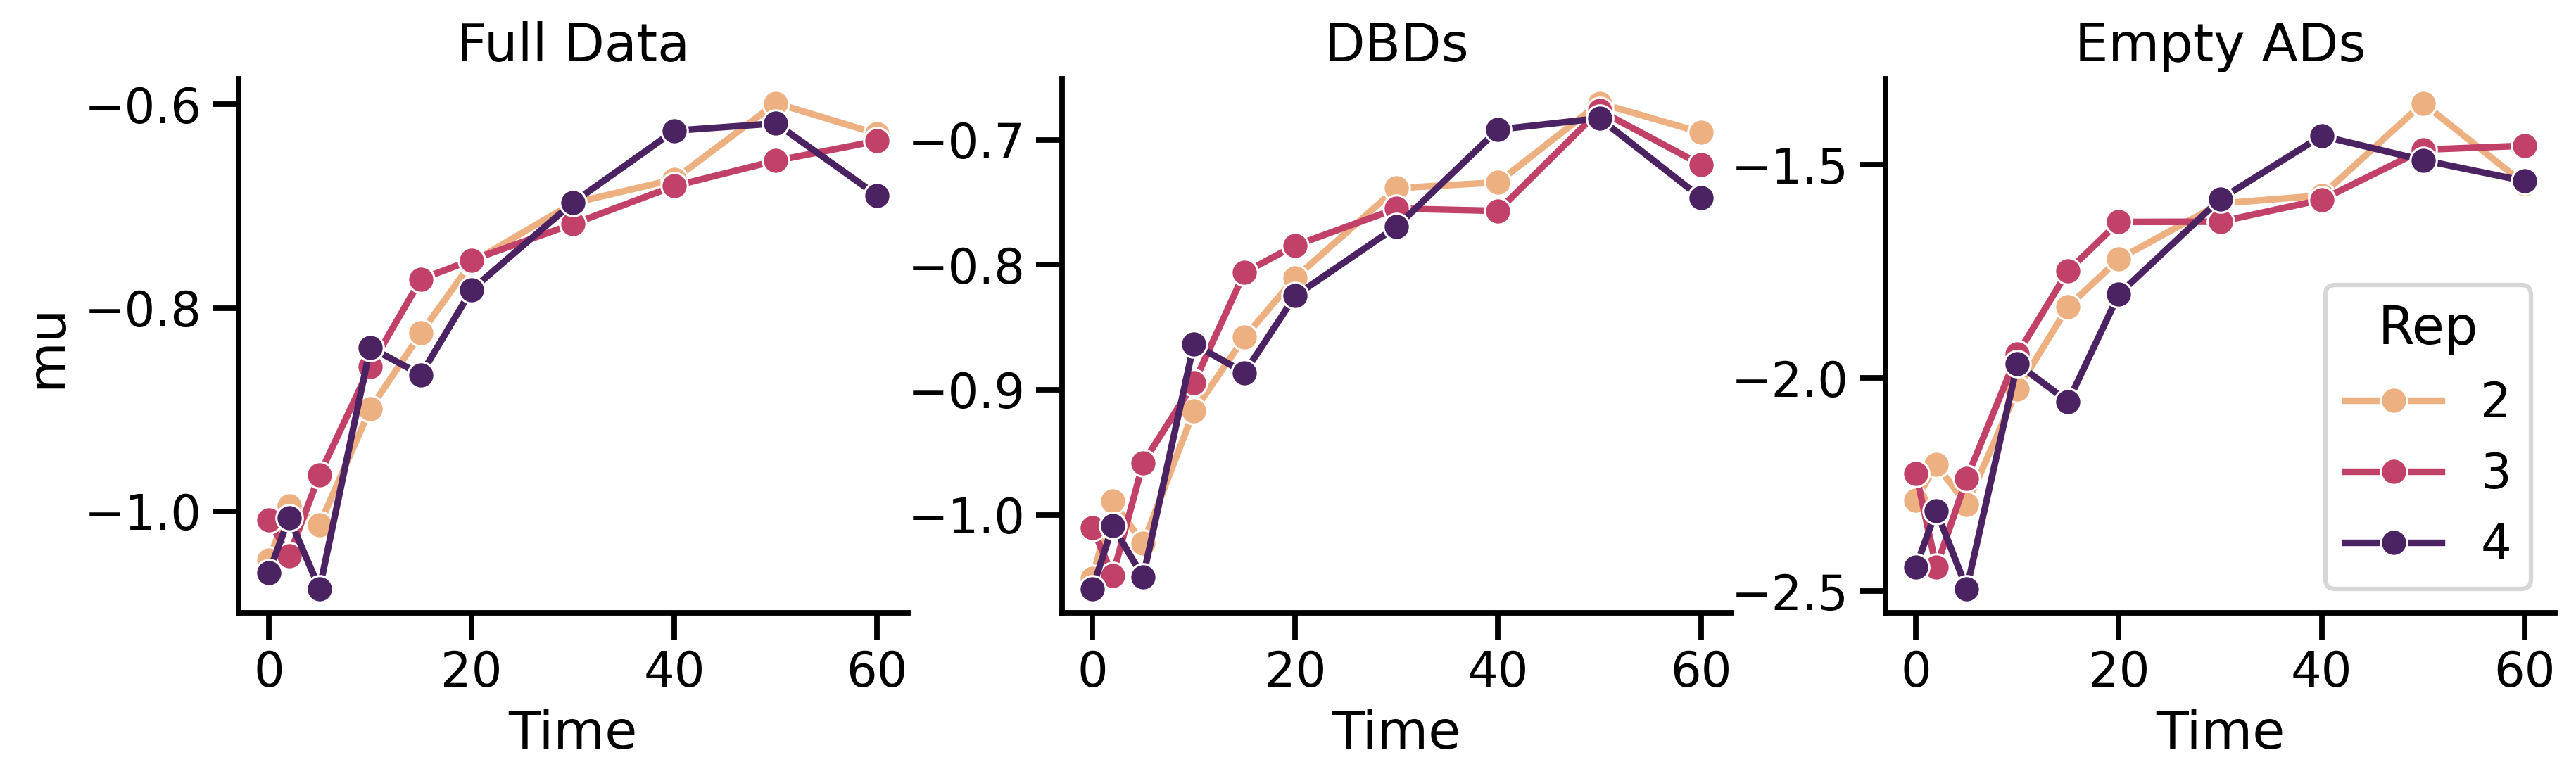

In [6]:
fig, axs = compare_normalizations("mu", "Normal Distribution\nMean")

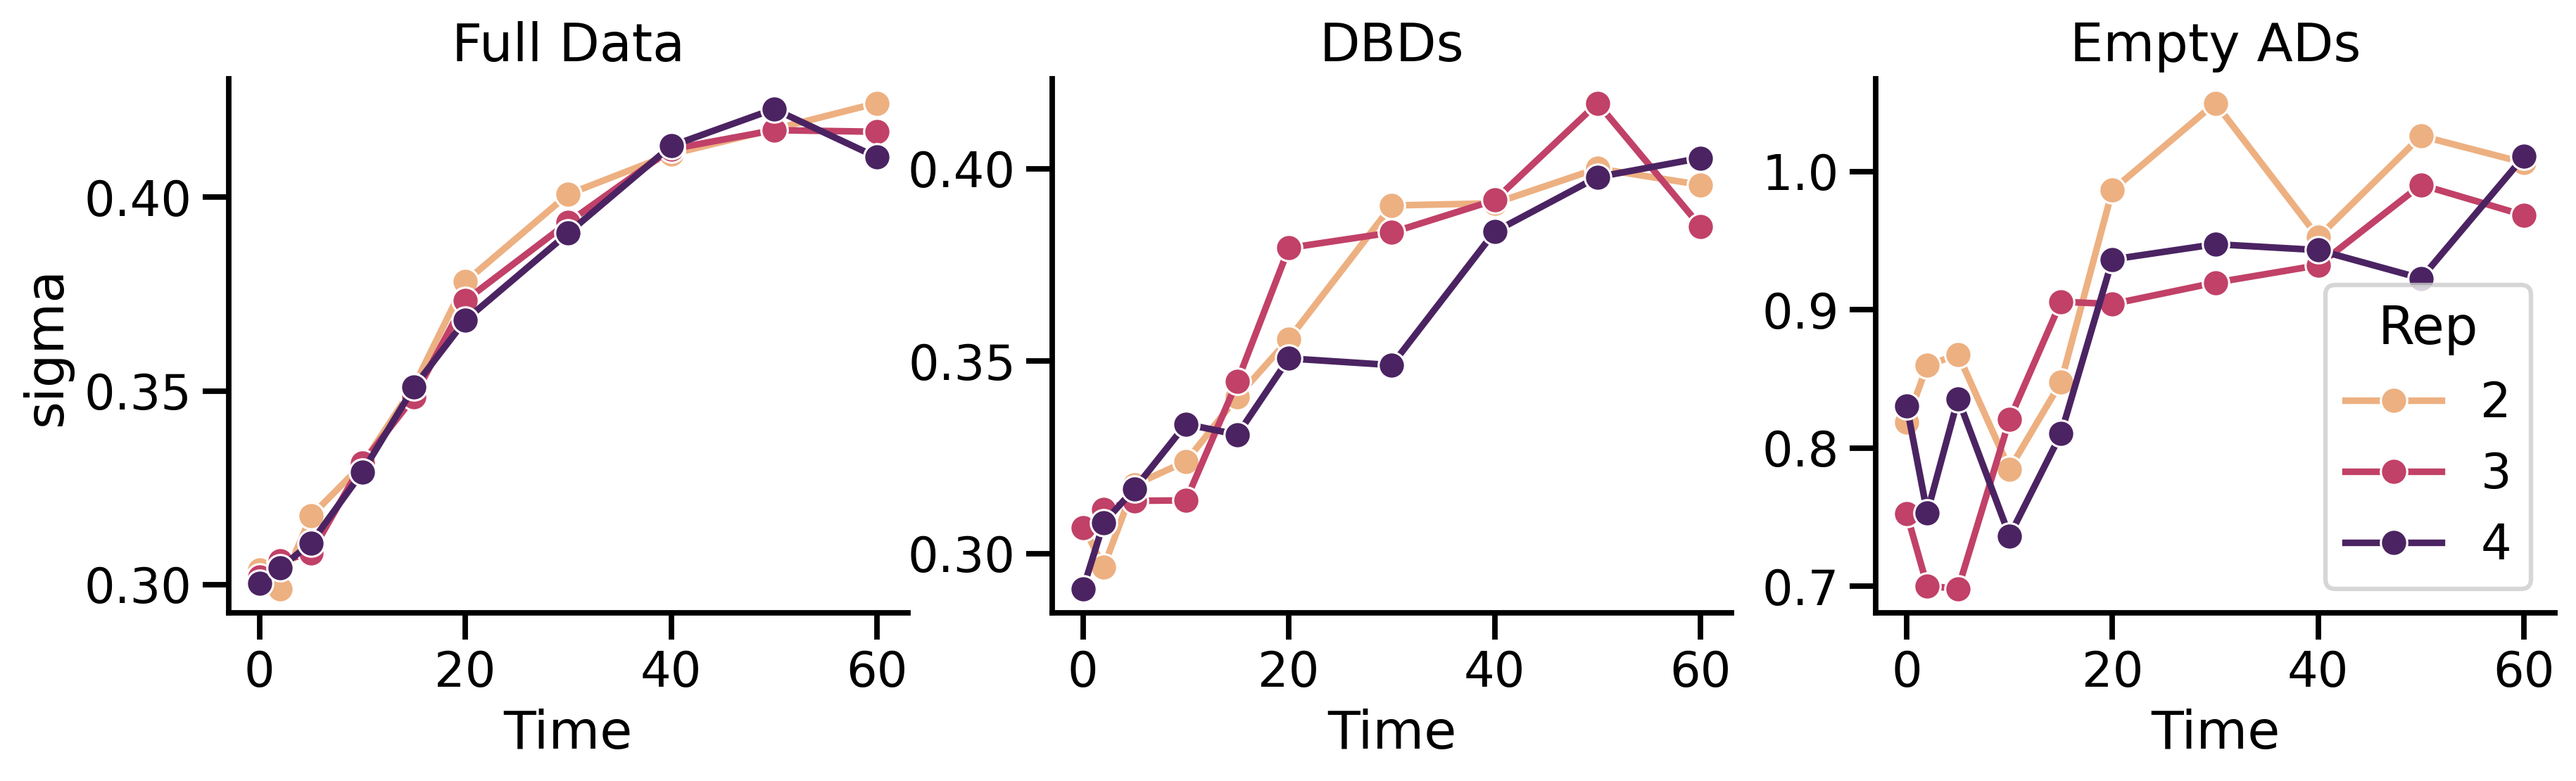

In [7]:
fig, axs = compare_normalizations("sigma", "Normal Distribution\nStandard Deviation")

Text(-0.05, 0.5, 'Percent Active')

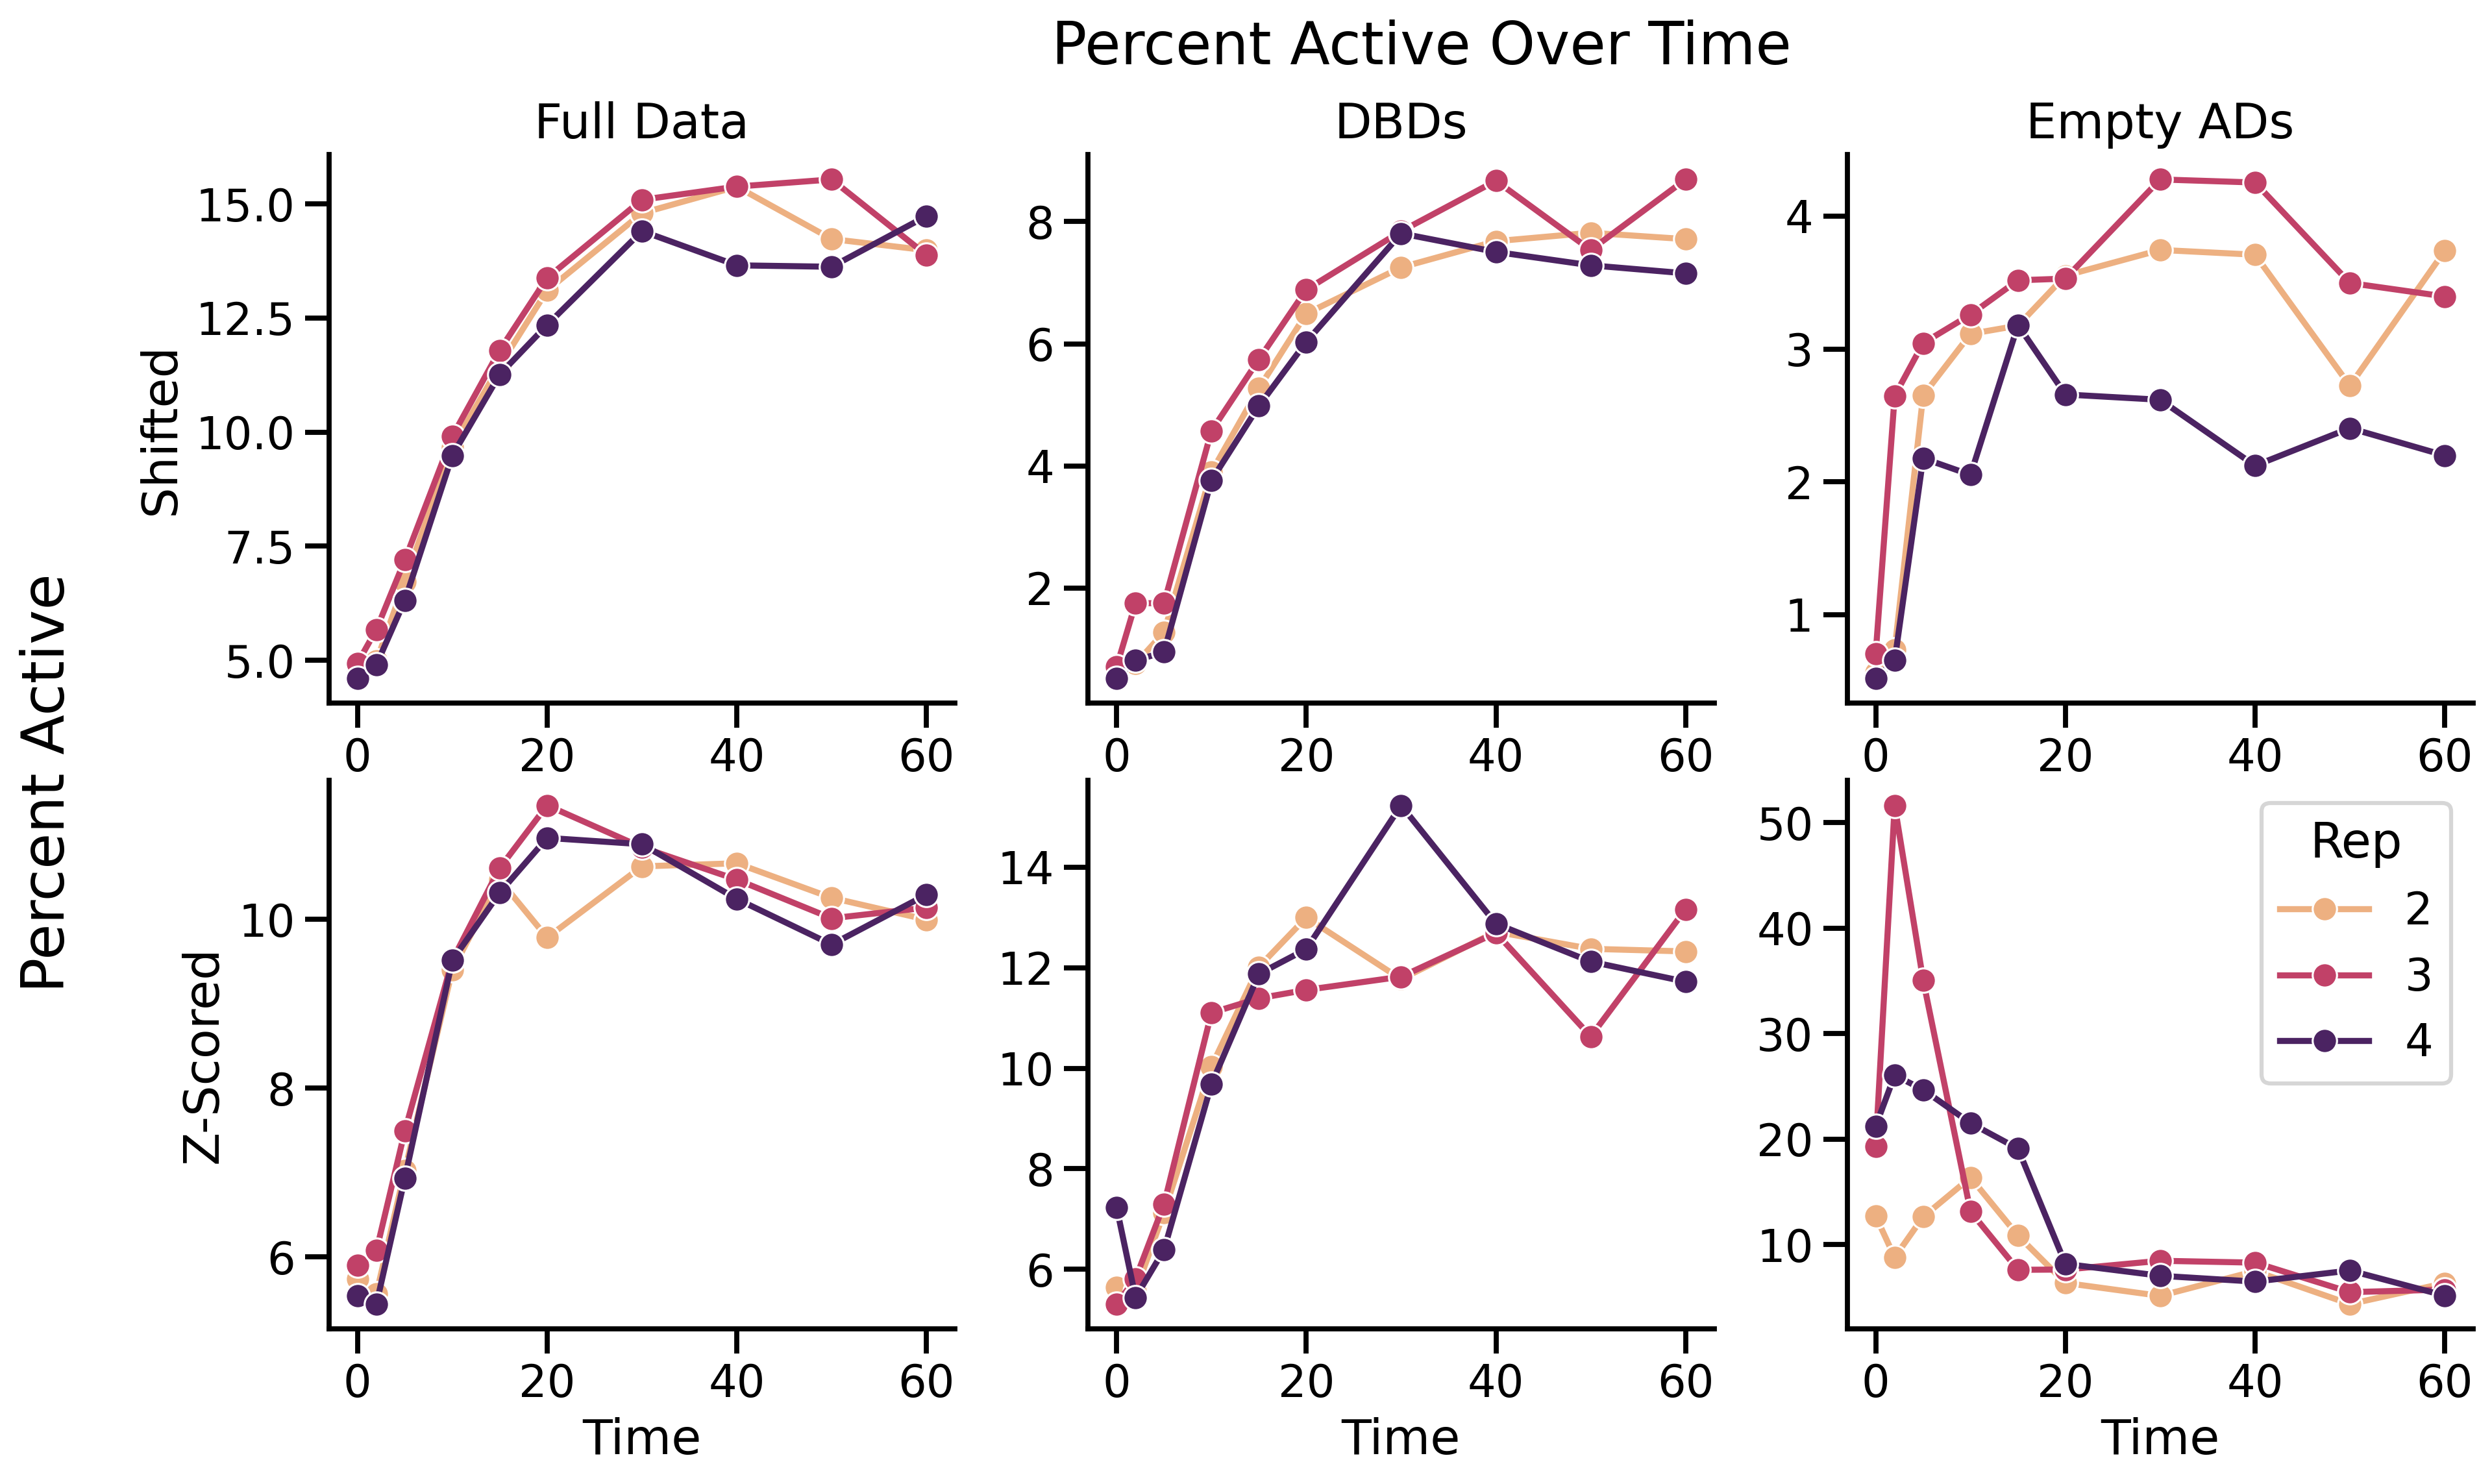

In [8]:
fig, axs = compare_normalizations(["shifted_active", "z-score_active"], "Percent Active")
axs = axs.flatten()
axs[0].set_ylabel("Shifted")
axs[3].set_ylabel("Z-Scored")
fig.suptitle("Percent Active Over Time", y = 1.06, x = 0.55)
fig.supylabel("Percent Active", x = -0.05)

# Controls

In [9]:
chopTF_controls = pd.read_csv("../../../data/chopTFs_controls.csv", index_col = 0)
chopTF_controls

,ADseq,Name,group
59,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2
65,TDAIDEEVLMSLVIEMGLDRIKELPELALGQNEADAMTDA,CITED2_ARO2A_0,CITED2
63,TDFIDEEVAMSAVIEMGADRIKEAPEAWAGQNEFDFMTDF,CITED2_L2A_0,CITED2
61,TDFIDEEVIMSIVIEMGIDRIKEIPEIWIGQNEFDFMTDF,CITED2_L2I_0,CITED2
67,TDAIDEEVAMSAVIEMGADRIKEAPEAAAGQNEADAMTDA,CITED2_LWF2A_0,CITED2
11,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,GCN4_CAAD40_0,GCN4_CAAD
17,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,GCN4_CAAD40_7As_0,GCN4_CAAD
15,STDSTPAAEAENAEDNSKEWTSLFDNDIPVTTDDVSLADK,GCN4_CAAD40_MFYL_A_0,GCN4_CAAD
13,STDSTPMFEYENLEDNSKEATSAADNDIPVTTDDVSLADK,GCN4_CAAD40_WLF_A_0,GCN4_CAAD
21,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,GCN4alt_0,GCN4_altCAAD


In [10]:
dbd_norm_activities = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities.csv")
dbd_norm_activities = pd.merge(chopTF_controls, dbd_norm_activities)
dbd_norm_activities = dbd_norm_activities[["ADseq", "Name", "group", "time", "rep", "z-scored_activity", "shifted_activity"]]
dbd_norm_activities = dbd_norm_activities.groupby(["ADseq", "rep", "time", "Name", "group"])[["z-scored_activity", "shifted_activity"]].agg(["mean", "std"]).reset_index()
dbd_norm_activities.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in dbd_norm_activities.columns]
dbd_norm_activities = dbd_norm_activities[dbd_norm_activities["rep_"] == 2]
dbd_norm_activities

,ADseq_,rep_,time_,Name_,group_,z-scored_activity_mean,z-scored_activity_std,shifted_activity_mean,shifted_activity_std
0,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,0,Rap1_Aro2A_0,Rap1,0.415570,0.359494,0.127702,0.110470
1,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,2,Rap1_Aro2A_0,Rap1,0.634196,1.342948,0.188056,0.398220
2,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,5,Rap1_Aro2A_0,Rap1,0.796266,0.601221,0.253103,0.191106
3,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,10,Rap1_Aro2A_0,Rap1,0.892648,0.985549,0.289196,0.319294
4,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,15,Rap1_Aro2A_0,Rap1,1.109166,1.159571,0.377938,0.395113
...,...,...,...,...,...,...,...,...,...
1594,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,20,Rap1_0,Rap1,4.967056,1.029454,1.767057,0.366234
1595,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,30,Rap1_0,Rap1,4.919628,0.687424,1.920946,0.268416
1596,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,40,Rap1_0,Rap1,4.585401,0.579383,1.793116,0.226567
1597,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,50,Rap1_0,Rap1,4.496431,0.590833,1.798956,0.236384


In [11]:
empty_AD_norm_activities = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/empty_AD_time_normalized_activities.csv")
empty_AD_norm_activities = pd.merge(chopTF_controls, empty_AD_norm_activities)
empty_AD_norm_activities = empty_AD_norm_activities[["ADseq", "Name", "group", "time", "rep", "z-scored_activity", "shifted_activity"]]
empty_AD_norm_activities = empty_AD_norm_activities.groupby(["ADseq", "rep", "time", "Name", "group"])[["z-scored_activity", "shifted_activity"]].agg(["mean", "std"]).reset_index()
empty_AD_norm_activities.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in empty_AD_norm_activities.columns]
empty_AD_norm_activities = empty_AD_norm_activities[empty_AD_norm_activities["rep_"] == 2]
empty_AD_norm_activities

,ADseq_,rep_,time_,Name_,group_,z-scored_activity_mean,z-scored_activity_std,shifted_activity_mean,shifted_activity_std
0,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,0,Rap1_Aro2A_0,Rap1,1.664596,0.134929,1.362850,0.110470
1,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,2,Rap1_Aro2A_0,Rap1,1.630986,0.463216,1.402136,0.398220
2,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,5,Rap1_Aro2A_0,Rap1,1.760551,0.220288,1.527328,0.191106
3,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,10,Rap1_Aro2A_0,Rap1,1.781805,0.406892,1.398211,0.319294
4,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,15,Rap1_Aro2A_0,Rap1,1.595448,0.466190,1.352201,0.395113
...,...,...,...,...,...,...,...,...,...
1594,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,20,Rap1_0,Rap1,2.714141,0.371254,2.677441,0.366234
1595,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,30,Rap1_0,Rap1,2.642468,0.255792,2.772880,0.268416
1596,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,40,Rap1_0,Rap1,2.762258,0.237894,2.630733,0.226567
1597,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,50,Rap1_0,Rap1,2.421360,0.230491,2.483258,0.236384


In [12]:
full_norm_activities = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/full_data_time_normalized_activities.csv")
full_norm_activities["ADseq"] = full_norm_activities["seq"]
full_norm_activities = pd.merge(chopTF_controls, full_norm_activities)
full_norm_activities = full_norm_activities[["ADseq", "Name", "group", "time", "rep", "z-scored_activity", "shifted_activity"]]
full_norm_activities = full_norm_activities.groupby(["ADseq", "rep", "time", "Name", "group"])[["z-scored_activity", "shifted_activity"]].agg(["mean", "std"]).reset_index()
full_norm_activities.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in full_norm_activities.columns]
full_norm_activities = full_norm_activities[full_norm_activities["rep_"] == 2]
full_norm_activities

,ADseq_,rep_,time_,Name_,group_,z-scored_activity_mean,z-scored_activity_std,shifted_activity_mean,shifted_activity_std
0,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,0,Rap1_Aro2A_0,Rap1,0.409753,0.363547,0.124510,0.110470
1,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,2,Rap1_Aro2A_0,Rap1,0.648027,1.332188,0.193710,0.398220
2,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,5,Rap1_Aro2A_0,Rap1,0.766229,0.601546,0.243424,0.191106
3,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,10,Rap1_Aro2A_0,Rap1,0.819491,0.964389,0.271321,0.319294
4,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,15,Rap1_Aro2A_0,Rap1,0.981211,1.124904,0.344643,0.395113
...,...,...,...,...,...,...,...,...,...
1594,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,20,Rap1_0,Rap1,4.526782,0.968378,1.711998,0.366234
1595,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,30,Rap1_0,Rap1,4.688505,0.669706,1.879135,0.268416
1596,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,40,Rap1_0,Rap1,4.214199,0.551078,1.732603,0.226567
1597,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,50,Rap1_0,Rap1,4.135384,0.566068,1.726888,0.236384


In [13]:
pool_umi_norm_activities = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/pool_size_read_depth_norm_activities.csv")
pool_umi_norm_activities["ADseq"] = pool_umi_norm_activities["AD_protein"]
pool_umi_norm_activities = pd.merge(chopTF_controls, pool_umi_norm_activities)
pool_umi_norm_activities = pool_umi_norm_activities[["ADseq", "Name", "group", "time", "rep", "score_umi_only", "score_umi_pool_norm"]]
pool_umi_norm_activities = pool_umi_norm_activities.groupby(["ADseq", "rep", "time", "Name", "group"])[["score_umi_only", "score_umi_pool_norm"]].agg(["mean", "std"]).reset_index()
pool_umi_norm_activities.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in pool_umi_norm_activities.columns]
pool_umi_norm_activities = pool_umi_norm_activities[pool_umi_norm_activities["rep_"] == 2]
pool_umi_norm_activities

,ADseq_,rep_,time_,Name_,group_,score_umi_only_mean,score_umi_only_std,score_umi_pool_norm_mean,score_umi_pool_norm_std
0,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,0,Rap1_Aro2A_0,Rap1,0.330311,0.254366,-2.622383,0.254366
1,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,2,Rap1_Aro2A_0,Rap1,0.370302,0.916936,-1.298523,0.916936
2,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,5,Rap1_Aro2A_0,Rap1,0.398879,0.440037,-1.159211,0.440037
3,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,10,Rap1_Aro2A_0,Rap1,0.067707,0.735202,-0.972840,0.735202
4,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,15,Rap1_Aro2A_0,Rap1,0.042225,0.909782,-0.782096,0.909782
...,...,...,...,...,...,...,...,...,...
1594,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,20,Rap1_0,Rap1,3.023167,0.843285,2.524550,0.843285
1595,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,30,Rap1_0,Rap1,3.245447,0.618050,2.987666,0.618050
1596,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,40,Rap1_0,Rap1,2.884054,0.521690,2.973005,0.521690
1597,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,50,Rap1_0,Rap1,2.865138,0.544293,3.208906,0.544293


In [14]:
# norm_merged = pd.merge(dbd_norm_activities, empty_AD_norm_activities, on = ["ADseq_", "rep_", "time_", "Name_", "group_"], suffixes = ("_DBD", "_emptyAD"))
# norm_merged

In [15]:
# norm_merged = pd.merge(norm_merged, full_norm_activities, on = ["ADseq_", "rep_", "time_", "Name_", "group_"], suffixes = ("", "_full"))
# norm_merged

In [16]:
# norm_merged = pd.merge(norm_merged, pool_umi_norm_activities, on = ["ADseq_", "rep_", "time_", "Name_", "group_"], suffixes = ("", "_pool_umi"))
# norm_merged

In [17]:
# norm_merged.columns

In [18]:
# norm_merged["group_"].unique()

In [19]:
pool_umi_norm_activities

,ADseq_,rep_,time_,Name_,group_,score_umi_only_mean,score_umi_only_std,score_umi_pool_norm_mean,score_umi_pool_norm_std
0,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,0,Rap1_Aro2A_0,Rap1,0.330311,0.254366,-2.622383,0.254366
1,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,2,Rap1_Aro2A_0,Rap1,0.370302,0.916936,-1.298523,0.916936
2,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,5,Rap1_Aro2A_0,Rap1,0.398879,0.440037,-1.159211,0.440037
3,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,10,Rap1_Aro2A_0,Rap1,0.067707,0.735202,-0.972840,0.735202
4,AAIPENELLDEDTMNAISSLKNDLSNISNSLPAEAPHEIA,2,15,Rap1_Aro2A_0,Rap1,0.042225,0.909782,-0.782096,0.909782
...,...,...,...,...,...,...,...,...,...
1594,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,20,Rap1_0,Rap1,3.023167,0.843285,2.524550,0.843285
1595,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,30,Rap1_0,Rap1,3.245447,0.618050,2.987666,0.618050
1596,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,40,Rap1_0,Rap1,2.884054,0.521690,2.973005,0.521690
1597,YAIPENELLDEDTMNFISSLKNDLSNISNSLPFEYPHEIA,2,50,Rap1_0,Rap1,2.865138,0.544293,3.208906,0.544293


In [20]:
plot_configs = [
    {"df": pool_umi_norm_activities, "y_mean": "score_umi_only_mean", "y_std": "score_umi_only_std", "title": "UMI Count"},
    {"df": pool_umi_norm_activities, "y_mean": "score_umi_pool_norm_mean", "y_std": "score_umi_pool_norm_std", "title": "UMI Count & Pool Size"},
    
    {"df": full_norm_activities, "y_mean": "shifted_activity_mean", "y_std": "shifted_activity_std", "title": "Full Shift"},
    {"df": full_norm_activities, "y_mean": "z-scored_activity_mean", "y_std": "z-scored_activity_std", "title": "Full Z-Score"},
    
    {"df": dbd_norm_activities, "y_mean": "shifted_activity_mean", "y_std": "shifted_activity_std", "title": "DBD Shift"},
    {"df": dbd_norm_activities, "y_mean": "z-scored_activity_mean", "y_std": "z-scored_activity_std", "title": "DBD Z-Score"},

    {"df": empty_AD_norm_activities, "y_mean": "shifted_activity_mean", "y_std": "shifted_activity_std", "title": "Empty AD Shift"},
    {"df": empty_AD_norm_activities, "y_mean": "z-scored_activity_mean", "y_std": "z-scored_activity_std", "title": "Empty AD Z-Score"},
     # add 4 more here to make 8 total
]

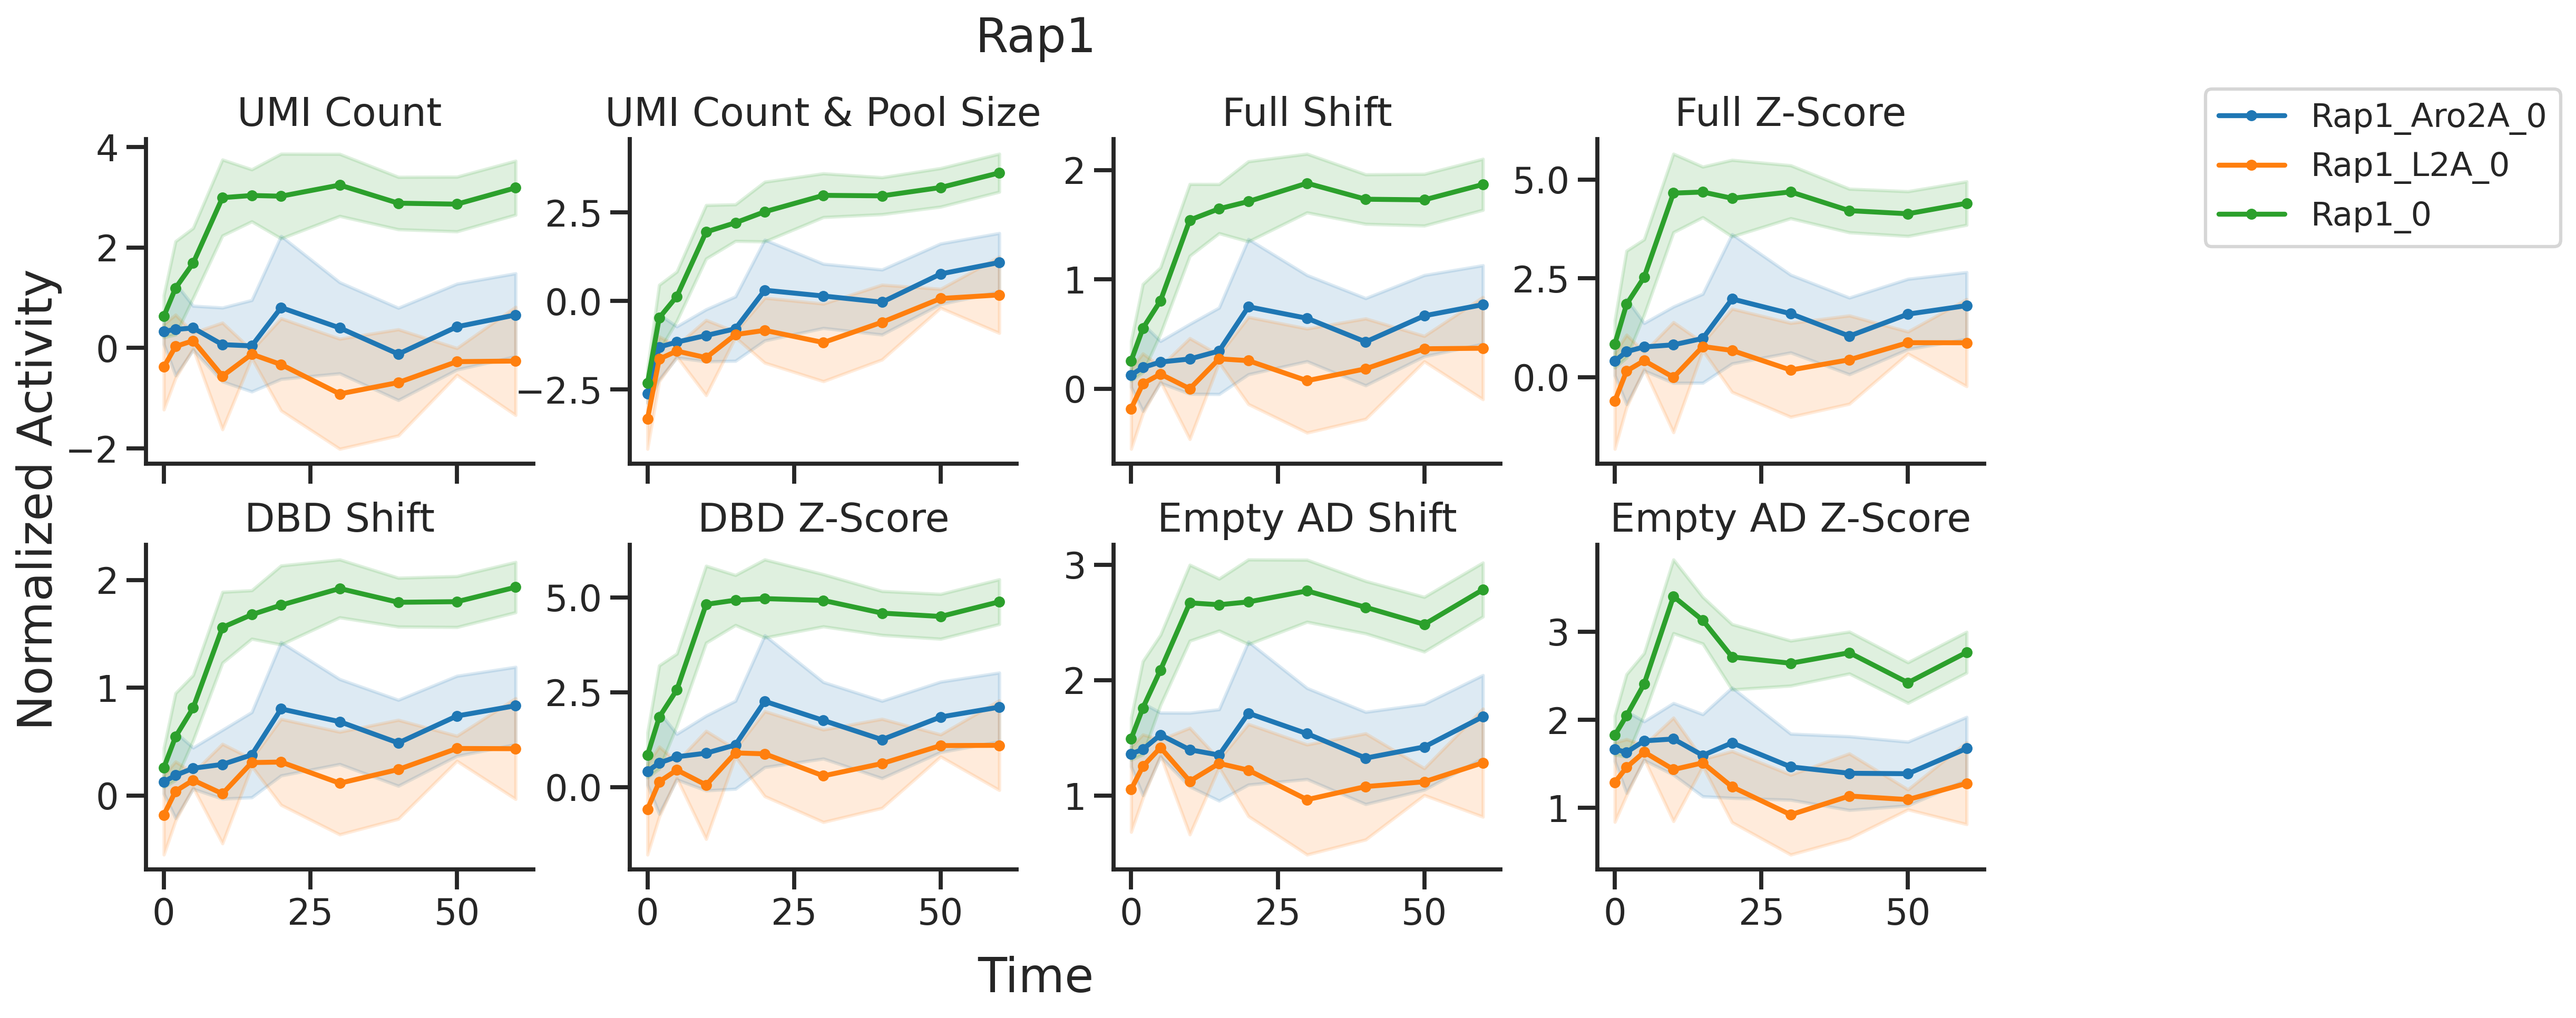

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks')
sns.set_context('talk')

save_dir = Path("../../../output/paper_figs/")

for group_name in pool_umi_norm_activities["group_"].unique():

    fig, axs = plt.subplots(2, 4, figsize=(15, 6), sharex=True, dpi=300)
    axs = axs.flatten()

    # Keep track of handles and labels for the legend
    handles = []
    labels = []

    for ax, cfg in zip(axs, plot_configs):

        df = cfg["df"]
        y_mean_col = cfg["y_mean"]
        y_std_col = cfg["y_std"]

        sub = df[df["group_"] == group_name].copy()

        palette = sns.color_palette("tab10", n_colors=sub["ADseq_"].nunique())

        for i, (adseq, subdf) in enumerate(sub.groupby("ADseq_")):
            subdf = subdf.sort_values("time_")

            label = subdf["Name_"].iloc[0]

            x = subdf["time_"]
            y = subdf[y_mean_col]
            yerr = subdf[y_std_col]

            color = palette[i]

            line, = ax.plot(
                x, y,
                color=color,
                label=label,
                marker='o',
                markersize=4
            )

            ax.fill_between(
                x,
                y - yerr,
                y + yerr,
                color=color,
                alpha=0.15
            )

            # Only add unique labels
            if label not in labels:
                handles.append(line)
                labels.append(label)

        ax.set_title(cfg["title"])
        ax.set_xlabel("")
        ax.set_ylabel("")

    plt.subplots_adjust(wspace=0.25, hspace=0.25)

    # Global labels and title
    fig.supxlabel("Time", y=-0.03)
    fig.supylabel("Normalized Activity", x=0.07)
    fig.suptitle(group_name, y=1.01)

    # Add a single legend outside the plot
    fig.legend(
        handles,
        [_[:30] for _ in labels],
        bbox_to_anchor=(1.15, 0.95),
        loc="upper right",
        fontsize='small',
        frameon=True
    )

    sns.despine()

    # clean filename
    safe_name = (
        str(group_name)
        .replace(" ", "_")
        .replace("/", "_")
    )

    fig.savefig(
        save_dir / f"S20_time_course_normalization_alternatives_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        save_dir / f"S20_time_course_normalization_alternatives_{safe_name}.pdf",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

# Saving control plots as ppt

In [37]:
! pip install python-pptx

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 8.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.8 MB/s eta 0:00:00


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from pptx import Presentation
from pptx.util import Inches
import io

sns.set_style('ticks')
sns.set_context('talk')

# Create a new PowerPoint presentation with default 16:9 slides
prs = Presentation()
prs.slide_width = Inches(13.33)  # 16:9 width in inches
prs.slide_height = Inches(7.5)   # 16:9 height in inches

for group_name in pool_umi_norm_activities["group_"].unique():
    
    fig, axs = plt.subplots(2, 4, figsize=(15, 6), sharex=True, dpi=300)
    axs = axs.flatten()
    
    handles, labels = [], []

    for ax, cfg in zip(axs, plot_configs):
        df = cfg["df"]
        y_mean_col = cfg["y_mean"]
        y_std_col = cfg["y_std"]
        sub = df[df["group_"] == group_name].copy()
        palette = sns.color_palette("tab10", n_colors=sub["ADseq_"].nunique())

        for i, (adseq, subdf) in enumerate(sub.groupby("ADseq_")):
            subdf = subdf.sort_values("time_")
            label = subdf["Name_"].iloc[0]
            x = subdf["time_"]
            y = subdf[y_mean_col]
            yerr = subdf[y_std_col]
            color = palette[i]
            line, = ax.plot(x, y, color=color, label=label, marker='o', markersize=4)
            ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.15)
            if label not in labels:
                handles.append(line)
                labels.append(label)

        ax.set_title(cfg["title"])
        ax.set_xlabel("")
        ax.set_ylabel("")

    plt.subplots_adjust(wspace=0.25, hspace=0.25)
    fig.supxlabel("Time", y=-0.03)
    fig.supylabel("Normalized Activity", x=0.07)
    fig.suptitle(group_name, y=1.01)
    fig.legend(handles, [_[:30] for _ in labels], bbox_to_anchor=(1.1, 0.95),
               loc="upper right", fontsize='small', frameon=True)
    sns.despine()

    # Save figure to in-memory PNG
    image_stream = io.BytesIO()
    fig.savefig(image_stream, format='png', bbox_inches='tight', dpi=300)
    plt.close(fig)
    image_stream.seek(0)

    # Add a blank slide
    slide_layout = prs.slide_layouts[5]  # blank
    slide = prs.slides.add_slide(slide_layout)

    # Figure size in inches
    fig_width, fig_height = 15, 6
    fig_width_emu = Inches(fig_width)
    fig_height_emu = Inches(fig_height)

    # Slide dimensions in EMU
    slide_width = prs.slide_width
    slide_height = prs.slide_height

    # Center the figure on the slide
    left = (slide_width - fig_width_emu) / 2
    top = (slide_height - fig_height_emu) / 2

    # Add figure to slide
    slide.shapes.add_picture(image_stream, left, top, width=fig_width_emu, height=fig_height_emu)

# Save the presentation
prs.save("../../../output/ChopTFs_control_activity_plots.pptx")
print("Presentation saved!")

Presentation saved!
